<a href="https://colab.research.google.com/github/abhi123108/50daysLeetCodeChallange/blob/main/MultiModelDeepFakeProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##MOUNT DRIVE.


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##LIBRARIES.

In [ ]:
import os
import random
import shutil
import numpy as np
import pandas as pd
import torch

from glob import glob

# RANDOM SEEDS

random.seed(42)

np.random.seed(42)

torch.manual_seed(42)

print("Libraries Imported")

Libraries Imported


##GLOBAL PATH.

In [ ]:
# MAIN PROJECT ROOT

import os

PROJECT_ROOT = "/content/drive/MyDrive/Multimodal_Deepfake_Project"

os.makedirs(PROJECT_ROOT, exist_ok=True)

print("project root created")

project root created


##FOLDER STRUCTURE

In [ ]:
folders = [

    # ORIGINAL IMAGE DATASET
    "original_images/real",
    "original_images/fake",

    # IMAGE DATASET
    "image_dataset/train/real",
    "image_dataset/train/fake",

    "image_dataset/test/real",
    "image_dataset/test/fake",

    # AUDIO DATASET
    "audio_dataset/raw_audio",
    "audio_dataset/metadata",

    # IMAGE PIPELINE
    "image_pipeline",

    # AUDIO PIPELINE
    "audio_pipeline",

    # FUSION
    "fusion",

    # CHECKPOINTS
    "checkpoints/image",
    "checkpoints/audio",
    "checkpoints/fusion",

    # RESULTS
    "results",

    # LOGS
    "logs",

    # NOTEBOOKS
    "notebooks",

    # APP
    "app"
]

for folder in folders:

    os.makedirs(
        os.path.join(PROJECT_ROOT, folder),
        exist_ok=True
    )

print("All folders created successfully")

All folders created successfully


##IMAGE SOURCE PATH

In [ ]:
SOURCE_IMAGE_PATH = os.path.join(
    PROJECT_ROOT,
    "original_images"
)

##IMAGE SPLIT

In [ ]:
DEST_PATH = os.path.join(
    PROJECT_ROOT,
    "image_dataset"
)

classes = ["real", "fake"]

for cls in classes:

    image_paths = glob(
        os.path.join(
            SOURCE_IMAGE_PATH,
            cls,
            "*"
        )
    )

    random.shuffle(image_paths)

    split_idx = int(
        0.8 * len(image_paths)
    )

    train_files = image_paths[:split_idx]

    test_files = image_paths[split_idx:]

    print(f"\n{cls.upper()}")

    print("Train:", len(train_files))

    print("Test :", len(test_files))

    # TRAIN

    for file in train_files:

        filename = os.path.basename(file)

        dst = os.path.join(
            DEST_PATH,
            "train",
            cls,
            filename
        )

        shutil.move(file, dst)

    # TEST

    for file in test_files:

        filename = os.path.basename(file)

        dst = os.path.join(
            DEST_PATH,
            "test",
            cls,
            filename
        )

        shutil.move(file, dst)

print("\nImage Splitting Completed")


REAL
Train: 5602
Test : 1401

FAKE
Train: 5608
Test : 1403

Image Splitting Completed


In [ ]:
import os
import random
import shutil

from glob import glob

random.seed(42)

# CREATE VAL FOLDERS

val_real_path = os.path.join(
    PROJECT_ROOT,
    "image_dataset/val/real"
)

val_fake_path = os.path.join(
    PROJECT_ROOT,
    "image_dataset/val/fake"
)

os.makedirs(val_real_path, exist_ok=True)

os.makedirs(val_fake_path, exist_ok=True)

# SPLIT TRAIN -> TRAIN + VAL

classes = ["real", "fake"]

for cls in classes:

    train_folder = os.path.join(
        PROJECT_ROOT,
        "image_dataset/train",
        cls
    )

    val_folder = os.path.join(
        PROJECT_ROOT,
        "image_dataset/val",
        cls
    )

    files = glob(
        os.path.join(train_folder, "*")
    )

    random.shuffle(files)

    # 10% OF ORIGINAL DATA
    # = 12.5% OF CURRENT TRAIN

    val_size = int(0.125 * len(files))

    val_files = files[:val_size]

    print(f"\n{cls.upper()}")

    print("Validation Files:",
          len(val_files))

    for file in val_files:

        filename = os.path.basename(
            file
        )

        dst = os.path.join(
            val_folder,
            filename
        )

        shutil.move(file, dst)

print("\nValidation Split Completed")


REAL
Validation Files: 700

FAKE
Validation Files: 701

Validation Split Completed


In [ ]:
from glob import glob

def count_files(path):

    return len(glob(path + "/*"))

print("TRAIN REAL:",
      count_files(
          os.path.join(
              PROJECT_ROOT,
              "image_dataset/train/real"
          )
      ))

print("VAL REAL:",
      count_files(
          os.path.join(
              PROJECT_ROOT,
              "image_dataset/val/real"
          )
      ))

print("TEST REAL:",
      count_files(
          os.path.join(
              PROJECT_ROOT,
              "image_dataset/test/real"
          )
      ))

TRAIN REAL: 4902
VAL REAL: 700
TEST REAL: 1401


In [ ]:
print("TRAIN FAKE:",
      count_files(
          os.path.join(
              PROJECT_ROOT,
              "image_dataset/train/fake"
          )
      ))

print("VAL FAKE:",
      count_files(
          os.path.join(
              PROJECT_ROOT,
              "image_dataset/val/fake"
          )
      ))

print("TEST FAKE:",
      count_files(
          os.path.join(
              PROJECT_ROOT,
              "image_dataset/test/fake"
          )
      ))

TRAIN FAKE: 4907
VAL FAKE: 701
TEST FAKE: 1403


##AUDIO ROOT PATH

In [ ]:
audio_root = os.path.join(
    PROJECT_ROOT,
    "audio_dataset/raw_audio"
)

print(audio_root)

/content/drive/MyDrive/Multimodal_Deepfake_Project/audio_dataset/raw_audio


##LOAD ASVSPOOF PROTOCOL FILE

In [ ]:
protocol_path = os.path.join(

    PROJECT_ROOT,

    "audio_dataset/raw_audio/ASVspoof2019_LA",

    "ASVspoof2019_LA_cm_protocols",

    "ASVspoof2019.LA.cm.train.trn.txt"
)

protocol_df = pd.read_csv(
    protocol_path,
    sep=" ",
    header=None
)

protocol_df.columns = [

    "speaker_id",

    "file_name",

    "unused1",

    "unused2",

    "label"
]

print(protocol_df["label"].value_counts())

label
spoof       22800
bonafide     2580
Name: count, dtype: int64


##CREATE AUDIO METADATA

In [ ]:
import os
import pandas as pd
from tqdm import tqdm

metadata = []

# VCTK (MIC1 ONLY)

vctk_root = os.path.join(
    PROJECT_ROOT,
    "audio_dataset/raw_audio/VCTK-Corpus-0.92/wav48_silence_trimmed"
)

for speaker in tqdm(os.listdir(vctk_root)):

    speaker_path = os.path.join(vctk_root, speaker)

    if not os.path.isdir(speaker_path):
        continue

    for file in os.listdir(speaker_path):

        if not file.endswith("_mic1.flac"):
            continue

        audio_path = os.path.join(
            speaker_path,
            file
        )

        metadata.append({

            "audio_path": audio_path,
            "label": 0,
            "speaker_id": speaker,
            "dataset": "VCTK"

        })

print("VCTK Done")

# LIBRISPEECH

libri_root = os.path.join(
    PROJECT_ROOT,
    "audio_dataset/raw_audio/LibriSpeech"
)

for root, dirs, files in os.walk(libri_root):

    for file in files:

        if not file.endswith(".flac"):
            continue

        audio_path = os.path.join(root, file)

        speaker_id = file.split("-")[0]

        metadata.append({

            "audio_path": audio_path,
            "label": 0,
            "speaker_id": speaker_id,
            "dataset": "LibriSpeech"

        })

print("LibriSpeech Done")

# ASVSPOOF (BONAFIDE + SPOOF)

protocol_path = os.path.join(

    PROJECT_ROOT,

    "audio_dataset/raw_audio/ASVspoof2019_LA",

    "ASVspoof2019_LA_cm_protocols",

    "ASVspoof2019.LA.cm.train.trn.txt"
)

protocol_df = pd.read_csv(
    protocol_path,
    sep=" ",
    header=None
)

protocol_df.columns = [

    "speaker_id",
    "file_name",
    "unused1",
    "unused2",
    "label"
]

asv_audio_root = os.path.join(

    PROJECT_ROOT,

    "audio_dataset/raw_audio/ASVspoof2019_LA",

    "ASVspoof2019_LA_train",

    "flac"
)

for _, row in tqdm(
    protocol_df.iterrows(),
    total=len(protocol_df)
):

    audio_path = os.path.join(
        asv_audio_root,
        row["file_name"] + ".flac"
    )

    if not os.path.exists(audio_path):
        continue

    label = 0 if row["label"] == "bonafide" else 1

    metadata.append({

        "audio_path": audio_path,
        "label": label,
        "speaker_id": row["speaker_id"],
        "dataset": "ASVspoof"

    })

print("ASVspoof Done")

# FOR_FAKE (TRAINING ONLY)

for_fake_root = os.path.join(

    PROJECT_ROOT,

    "audio_dataset/raw_audio/for-2seconds",

    "training",

    "fake"
)

for file in os.listdir(for_fake_root):

    if not file.endswith(".wav"):
        continue

    audio_path = os.path.join(
        for_fake_root,
        file
    )

    speaker_id = os.path.splitext(
        file
    )[0]

    metadata.append({

        "audio_path": audio_path,
        "label": 1,
        "speaker_id": f"FORF_{speaker_id}",
        "dataset": "FOR_FAKE"

    })

print("FOR_FAKE Done")

# DATAFRAME

metadata_df = pd.DataFrame(metadata)

print("\nTOTAL:", len(metadata_df))

print("\nDATASET COUNTS")
print(
    metadata_df["dataset"].value_counts()
)

print("\nLABEL COUNTS")
print(
    metadata_df["label"].value_counts()
)

print("\nUNIQUE SPEAKERS")
print(
    metadata_df.groupby("dataset")[
        "speaker_id"
    ].nunique()
)

100%|██████████| 111/111 [00:01<00:00, 66.99it/s]


VCTK Done
LibriSpeech Done


100%|██████████| 25380/25380 [00:19<00:00, 1296.12it/s]


ASVspoof Done
FOR_FAKE Done

TOTAL: 105352

DATASET COUNTS
dataset
VCTK           44455
LibriSpeech    28539
ASVspoof       25380
FOR_FAKE        6978
Name: count, dtype: int64

LABEL COUNTS
label
0    75574
1    29778
Name: count, dtype: int64

UNIQUE SPEAKERS
dataset
ASVspoof         20
FOR_FAKE       6978
LibriSpeech     251
VCTK            110
Name: speaker_id, dtype: int64


##BALANCED SAMPLING

In [ ]:
# REAL

vctk_df = metadata_df[
    metadata_df["dataset"] == "VCTK"
].sample(
    n=6000,
    random_state=42
)

libri_df = metadata_df[
    metadata_df["dataset"] == "LibriSpeech"
].sample(
    n=6500,
    random_state=42
)

asv_real_df = metadata_df[
    (metadata_df["dataset"] == "ASVspoof")
    &
    (metadata_df["label"] == 0)
].sample(
    n=2500,
    random_state=42
)

real_df = pd.concat([
    vctk_df,
    libri_df,
    asv_real_df
])

# FAKE

asv_fake_df = metadata_df[
    (metadata_df["dataset"] == "ASVspoof")
    &
    (metadata_df["label"] == 1)
].sample(
    n=10000,
    random_state=42
)

for_fake_df = metadata_df[
    metadata_df["dataset"] == "FOR_FAKE"
].sample(
    n=5000,
    random_state=42
)

fake_df = pd.concat([
    asv_fake_df,
    for_fake_df
])

# FINAL

balanced_df = pd.concat([
    real_df,
    fake_df
])

balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("TOTAL:", len(balanced_df))

print("\nLABELS")
print(balanced_df["label"].value_counts())

print("\nDATASETS")
print(
    balanced_df.groupby(
        ["dataset", "label"]
    ).size()
)

TOTAL: 30000

LABELS
label
0    15000
1    15000
Name: count, dtype: int64

DATASETS
dataset      label
ASVspoof     0         2500
             1        10000
FOR_FAKE     1         5000
LibriSpeech  0         6500
VCTK         0         6000
dtype: int64


Split

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

def speaker_split(df):

    speakers = df["speaker_id"].unique()

    train_spk, temp_spk = train_test_split(
        speakers,
        test_size=0.30,
        random_state=42
    )

    val_spk, test_spk = train_test_split(
        temp_spk,
        test_size=0.50,
        random_state=42
    )

    train_df = df[df["speaker_id"].isin(train_spk)]
    val_df   = df[df["speaker_id"].isin(val_spk)]
    test_df  = df[df["speaker_id"].isin(test_spk)]

    return train_df, val_df, test_df


def random_split(df):

    train_df, temp_df = train_test_split(
        df,
        test_size=0.30,
        random_state=42,
        shuffle=True
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=42,
        shuffle=True
    )

    return train_df, val_df, test_df

# VCTK

vctk_train, vctk_val, vctk_test = speaker_split(
    balanced_df[
        balanced_df["dataset"] == "VCTK"
    ]
)

# LibriSpeech

libri_train, libri_val, libri_test = speaker_split(
    balanced_df[
        balanced_df["dataset"] == "LibriSpeech"
    ]
)

# ASVspoof

asv_train, asv_val, asv_test = speaker_split(
    balanced_df[
        balanced_df["dataset"] == "ASVspoof"
    ]
)

# FOR_FAKE

for_train, for_val, for_test = random_split(
    balanced_df[
        balanced_df["dataset"] == "FOR_FAKE"
    ]
)

# MERGE

train_df = pd.concat([
    vctk_train,
    libri_train,
    asv_train,
    for_train
])

val_df = pd.concat([
    vctk_val,
    libri_val,
    asv_val,
    for_val
])

test_df = pd.concat([
    vctk_test,
    libri_test,
    asv_test,
    for_test
])

train_df = train_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

val_df = val_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

test_df = test_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("TRAIN:", len(train_df))
print("VAL  :", len(val_df))
print("TEST :", len(test_df))

print("\nTRAIN LABELS")
print(train_df["label"].value_counts())

print("\nVAL LABELS")
print(val_df["label"].value_counts())

print("\nTEST LABELS")
print(test_df["label"].value_counts())

TRAIN: 20949
VAL  : 4484
TEST : 4567

TRAIN LABELS
label
1    10523
0    10426
Name: count, dtype: int64

VAL LABELS
label
0    2271
1    2213
Name: count, dtype: int64

TEST LABELS
label
0    2303
1    2264
Name: count, dtype: int64


##SAVE CSV FILES

In [ ]:
metadata_dir = os.path.join(
    PROJECT_ROOT,
    "audio_dataset/metadata"
)

os.makedirs(metadata_dir, exist_ok=True)

train_df.to_csv(
    os.path.join(metadata_dir, "train.csv"),
    index=False
)

val_df.to_csv(
    os.path.join(metadata_dir, "val.csv"),
    index=False
)

test_df.to_csv(
    os.path.join(metadata_dir, "test.csv"),
    index=False
)

print("Audio V4 CSV Saved")

Audio V4 CSV Saved


##IMAGE TRANSFORMS.

In [ ]:
from torchvision import transforms

image_transform = transforms.Compose([

    transforms.Resize((380, 380)),

    transforms.RandomHorizontalFlip(),

    transforms.ToTensor(),

    transforms.Normalize(

        mean=[0.485, 0.456, 0.406],

        std=[0.229, 0.224, 0.225]
    )
])

print("Image Transforms Ready")

Image Transforms Ready


##IMAGE DATASET LOADING.

In [ ]:
from torchvision.datasets import ImageFolder

train_image_dataset = ImageFolder(

    root=os.path.join(
        PROJECT_ROOT,
        "image_dataset/train"
    ),

    transform=image_transform
)

val_image_dataset = ImageFolder(

    root=os.path.join(
        PROJECT_ROOT,
        "image_dataset/val"
    ),

    transform=image_transform
)

test_image_dataset = ImageFolder(

    root=os.path.join(
        PROJECT_ROOT,
        "image_dataset/test"
    ),

    transform=image_transform
)

print("Train Images:",
      len(train_image_dataset))

print("Val Images:",
      len(val_image_dataset))

print("Test Images:",
      len(test_image_dataset))

Train Images: 9809
Val Images: 1401
Test Images: 2804


##IMAGE DATALOADERS.

In [ ]:
from torch.utils.data import DataLoader

train_image_loader = DataLoader(

    train_image_dataset,

    batch_size=16,

    shuffle=True
)

val_image_loader = DataLoader(

    val_image_dataset,

    batch_size=16,

    shuffle=False
)

test_image_loader = DataLoader(

    test_image_dataset,

    batch_size=16,

    shuffle=False
)

print("Image DataLoaders Ready")

Image DataLoaders Ready


In [ ]:
!pip install transformers datasets -q

##AUDIO DATASET CLASS.

In [ ]:
import torch
import torchaudio
import pandas as pd

from torch.utils.data import Dataset


class AudioDataset(Dataset):

    def __init__(

        self,

        csv_file,

        sample_rate=16000,

        duration=3

    ):

        self.df = pd.read_csv(csv_file)

        self.sample_rate = sample_rate

        self.max_length = sample_rate * duration

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        audio_path = row["audio_path"]

        label = int(row["label"])

        waveform, sr = torchaudio.load(
            audio_path
        )

        # Stereo -> Mono

        if waveform.shape[0] > 1:

            waveform = waveform.mean(
                dim=0,
                keepdim=True
            )

        # Resample

        if sr != self.sample_rate:

            waveform = torchaudio.functional.resample(

                waveform,

                sr,

                self.sample_rate
            )

        waveform = waveform.squeeze(0)

        # Trim

        if len(waveform) > self.max_length:

            waveform = waveform[
                :self.max_length
            ]

        # Pad

        elif len(waveform) < self.max_length:

            pad_length = (

                self.max_length

                - len(waveform)
            )

            waveform = torch.nn.functional.pad(

                waveform,

                (0, pad_length)
            )

        return waveform, label

##AUDIO DATASET LOADING.

In [ ]:
train_csv = os.path.join(

    PROJECT_ROOT,

    "audio_dataset/metadata/train.csv"
)

val_csv = os.path.join(

    PROJECT_ROOT,

    "audio_dataset/metadata/val.csv"
)

test_csv = os.path.join(

    PROJECT_ROOT,

    "audio_dataset/metadata/test.csv"
)

train_dataset = AudioDataset(
    train_csv
)

val_dataset = AudioDataset(
    val_csv
)

test_dataset = AudioDataset(
    test_csv
)

print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

20949
4484
4567


##AUDIO DATALOADERS.

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=2,

    pin_memory=True
)

val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True
)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True
)

##OPTIONAL TEST CELL

In [ ]:
audio, label = next(
    iter(train_loader)
)

print(audio.shape)
print(label.shape)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


torch.Size([16, 48000])
torch.Size([16])


##DEVISE SETUP.

In [ ]:
device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"
)

print(device)

cuda


##IMPORTANT IMPORTS.

In [ ]:
import torch.nn as nn

from torchvision import models

##IMAGE MODEL.

In [ ]:
# EFFICIENTNET-B4

image_model = models.efficientnet_b4(

    weights="IMAGENET1K_V1"
)

# FINAL CLASSIFIER

in_features = image_model.classifier[1].in_features

image_model.classifier = nn.Sequential(

    nn.Dropout(0.4),

    nn.Linear(
        in_features,
        1
    )
)

image_model = image_model.to(device)

print(image_model)

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 153MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
            (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiv

##IMAGE LOSS + OPTIMIZER.

In [ ]:
image_criterion = nn.BCEWithLogitsLoss()

image_optimizer = torch.optim.AdamW(

    image_model.parameters(),

    lr=1e-4
)

image_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    image_optimizer,

    T_max=10
)

print("Image Training Setup Ready")

Image Training Setup Ready


##IMAGE TRAIN FUNCTION

In [ ]:
from tqdm import tqdm

def train_image_epoch(model, loader):

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    for images, labels in tqdm(loader):

        images = images.to(device)

        labels = labels.float().unsqueeze(1).to(device)

        # FORWARD

        outputs = model(images)

        loss = image_criterion(
            outputs,
            labels
        )

        # BACKWARD

        image_optimizer.zero_grad()

        loss.backward()

        image_optimizer.step()

        # METRICS

        preds = (
            torch.sigmoid(outputs) > 0.5
        ).float()

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

        running_loss += loss.item()

    epoch_loss = (
        running_loss / len(loader)
    )

    epoch_acc = (
        correct / total
    )

    return epoch_loss, epoch_acc

##IMAGE VALIDATION FUNCTION

In [ ]:
def validate_image_epoch(model, loader):

    model.eval()

    running_loss = 0

    correct = 0

    total = 0

    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(device)

            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)

            loss = image_criterion(
                outputs,
                labels
            )

            preds = (
                torch.sigmoid(outputs) > 0.5
            ).float()

            correct += (
                preds == labels
            ).sum().item()

            total += labels.size(0)

            running_loss += loss.item()

    epoch_loss = (
        running_loss / len(loader)
    )

    epoch_acc = (
        correct / total
    )

    return epoch_loss, epoch_acc

##IMAGE TRAINING LOOP

In [ ]:
best_val_acc = 0

EPOCHS = 20

for epoch in range(EPOCHS):

    print(f"\nEPOCH {epoch+1}/{EPOCHS}")

    # TRAIN

    train_loss, train_acc = train_image_epoch(

        image_model,

        train_image_loader
    )

    # VALIDATE

    val_loss, val_acc = validate_image_epoch(

        image_model,

        val_image_loader
    )

    # SCHEDULER

    image_scheduler.step()

    # PRINT

    print(f"\nTrain Loss: {train_loss:.4f}")

    print(f"Train Acc : {train_acc:.4f}")

    print(f"Val Loss  : {val_loss:.4f}")

    print(f"Val Acc   : {val_acc:.4f}")

    # SAVE BEST MODEL

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        save_path = os.path.join(

            PROJECT_ROOT,

            "checkpoints/image/best_image_model.pth"
        )

        torch.save(

            image_model.state_dict(),

            save_path
        )

        print("\nBest Model Saved")


EPOCH 1/20


100%|██████████| 88/88 [18:05<00:00, 12.33s/it]



Train Loss: 0.4247
Train Acc : 0.8066
Val Loss  : 0.2356
Val Acc   : 0.8986

Best Model Saved

EPOCH 2/20


100%|██████████| 88/88 [00:28<00:00,  3.07it/s]



Train Loss: 0.2163
Train Acc : 0.9100
Val Loss  : 0.1472
Val Acc   : 0.9358

Best Model Saved

EPOCH 3/20


...


Train Loss: 0.0276
Train Acc : 0.9896
Val Loss  : 0.2434
Val Acc   : 0.9465

EPOCH 19/20


100%|██████████| 88/88 [00:28<00:00,  3.08it/s]



Train Loss: 0.0352
Train Acc : 0.9883
Val Loss  : 0.2495
Val Acc   : 0.9443

EPOCH 20/20


100%|██████████| 88/88 [00:28<00:00,  3.06it/s]


Train Loss: 0.0286
Train Acc : 0.9898
Val Loss  : 0.2173
Val Acc   : 0.9472


In [ ]:
image_model.load_state_dict(
    torch.load(
        os.path.join(
            PROJECT_ROOT,
            "checkpoints/image/best_image_model.pth"
        ),
        map_location=device
    )
)

image_model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
            (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiv

In [ ]:
import os

print(
    os.path.exists(
        os.path.join(
            PROJECT_ROOT,
            "checkpoints/image/best_image_model.pth"
        )
    )
)

True


##IMAGE TEST EVALUATION

In [ ]:
from sklearn.metrics import classification_report

device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"
)

image_model.load_state_dict(

    torch.load(

        os.path.join(

            PROJECT_ROOT,

            "checkpoints/image/best_image_model.pth"
        ),

        map_location=device
    )
)

image_model = image_model.to(device)

image_model.eval()

all_preds = []

all_labels = []

with torch.no_grad():

    for images, labels in test_image_loader:

        images = images.to(device)

        outputs = image_model(images)

        preds = (

            torch.sigmoid(outputs) > 0.5

        ).int().cpu().numpy()

        all_preds.extend(
            preds.flatten()
        )

        all_labels.extend(
            labels.numpy()
        )

print(

    classification_report(

        all_labels,

        all_preds
    )
)

              precision    recall  f1-score   support

           0       0.96      0.95      0.96      1403
           1       0.95      0.96      0.96      1401

    accuracy                           0.96      2804
   macro avg       0.96      0.96      0.96      2804
weighted avg       0.96      0.96      0.96      2804



##CONFUSION METRICS

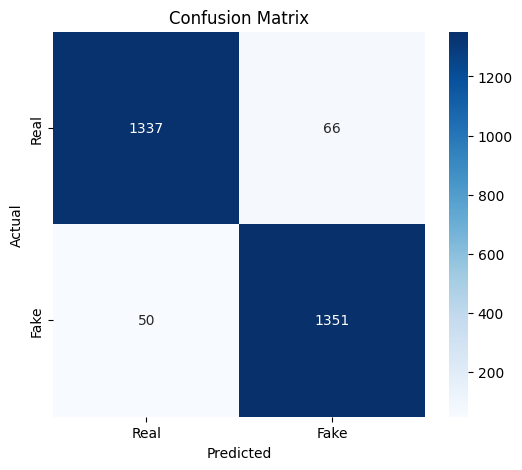

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Real","Fake"],
    yticklabels=["Real","Fake"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

##ROC CURVE

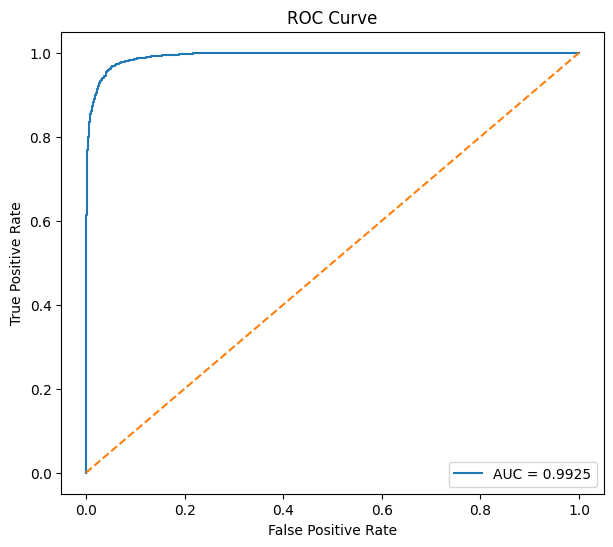

AUC Score: 0.9925254489334826


In [ ]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

image_model.eval()

y_true = []
y_score = []

with torch.no_grad():

    for images, labels in test_image_loader:

        images = images.to(device)

        outputs = image_model(images)

        probs = torch.sigmoid(
            outputs
        ).cpu().numpy()

        y_score.extend(
            probs.flatten()
        )

        y_true.extend(
            labels.numpy()
        )

fpr, tpr, _ = roc_curve(
    y_true,
    y_score
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

print("AUC Score:", roc_auc)

##ACCURACY AND LOSS CURVE

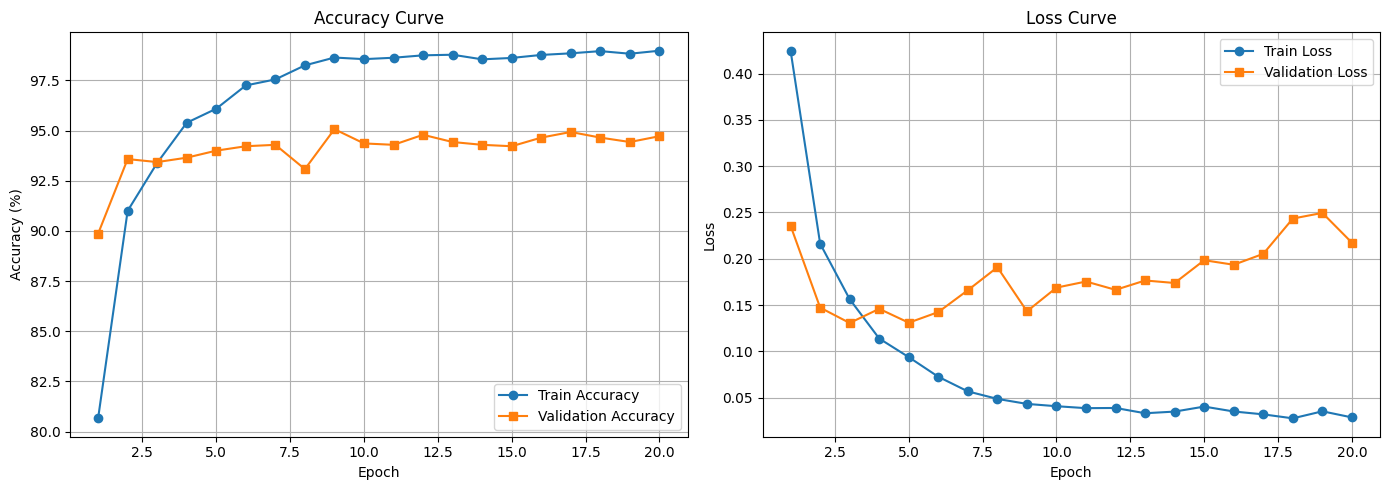

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, 21)

train_losses = [
0.4247,0.2163,0.1563,0.1138,0.0937,
0.0725,0.0567,0.0486,0.0432,0.0407,
0.0386,0.0388,0.0331,0.0349,0.0403,
0.0350,0.0319,0.0276,0.0352,0.0286
]

val_losses = [
0.2356,0.1472,0.1306,0.1459,0.1309,
0.1424,0.1660,0.1908,0.1432,0.1688,
0.1754,0.1664,0.1765,0.1738,0.1984,
0.1935,0.2053,0.2434,0.2495,0.2173
]

train_accs = [
80.66,91.00,93.39,95.39,96.09,
97.25,97.55,98.25,98.64,98.56,
98.63,98.75,98.78,98.55,98.62,
98.77,98.85,98.96,98.83,98.98
]

val_accs = [
89.86,93.58,93.43,93.65,94.00,
94.22,94.29,93.08,95.07,94.36,
94.29,94.79,94.43,94.29,94.22,
94.65,94.93,94.65,94.43,94.72
]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ACCURACY CURVE

ax[0].plot(
    epochs,
    train_accs,
    marker='o',
    label='Train Accuracy'
)

ax[0].plot(
    epochs,
    val_accs,
    marker='s',
    label='Validation Accuracy'
)

ax[0].set_title(
    "Accuracy Curve"
)

ax[0].set_xlabel(
    "Epoch"
)

ax[0].set_ylabel(
    "Accuracy (%)"
)

ax[0].legend()

ax[0].grid(True)

# LOSS CURVE

ax[1].plot(
    epochs,
    train_losses,
    marker='o',
    label='Train Loss'
)

ax[1].plot(
    epochs,
    val_losses,
    marker='s',
    label='Validation Loss'
)

ax[1].set_title(
    "Loss Curve"
)

ax[1].set_xlabel(
    "Epoch"
)

ax[1].set_ylabel(
    "Loss"
)

ax[1].legend()

ax[1].grid(True)

plt.tight_layout()

plt.show()

##AUDIO MODEL

In [ ]:
import torch
import torch.nn as nn

from transformers import (
    Wav2Vec2Model
)

In [ ]:
class Wav2Vec2Classifier(nn.Module):

    def __init__(self):

        super().__init__()

        self.wav2vec = Wav2Vec2Model.from_pretrained(
            "facebook/wav2vec2-base"
        )

        self.classifier = nn.Sequential(

            nn.Dropout(0.3),

            nn.Linear(
                768,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                256,
                1
            )
        )

    def forward(self, x):

        outputs = self.wav2vec(
            x
        )

        embeddings = outputs.last_hidden_state

        embeddings = embeddings.mean(
            dim=1
        )

        logits = self.classifier(
            embeddings
        )

        return logits

##MODEL LOAD

In [ ]:
import torch
import torch.nn as nn

from transformers import (
    Wav2Vec2Model
)


class AudioDeepfakeModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.backbone = Wav2Vec2Model.from_pretrained(

            "facebook/wav2vec2-base"
        )

        self.dropout = nn.Dropout(
            0.3
        )

        self.classifier = nn.Linear(

            768,

            2
        )

    def forward(

        self,

        x
    ):

        outputs = self.backbone(

            x
        )

        hidden_states = outputs.last_hidden_state

        pooled = hidden_states.mean(
            dim=1
        )

        pooled = self.dropout(
            pooled
        )

        logits = self.classifier(
            pooled
        )

        return logits

In [ ]:
DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = AudioDeepfakeModel()

model = model.to(
    DEVICE
)

print(
    "Device:",
    DEVICE
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cuda


##LOSS + OPTIMIZER

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=1e-5,

    weight_decay=1e-4
)

In [ ]:
dummy_audio = torch.randn(

    2,

    48000
).to(
    DEVICE
)

with torch.no_grad():

    out = model(
        dummy_audio
    )

print(out.shape)

torch.Size([2, 2])


##CHECKPOINT PATHS

In [ ]:
audio_checkpoint_path = os.path.join(
    PROJECT_ROOT,
    "checkpoints/audio/audio_checkpoint.pth"
)

best_audio_model_path = os.path.join(
    PROJECT_ROOT,
    "checkpoints/audio/best_audio_model.pth"
)

##RESUME CHECKPOINT

In [ ]:
import os

start_epoch = 0
best_val_acc = 0.0

if os.path.exists(audio_checkpoint_path):

    checkpoint = torch.load(
        audio_checkpoint_path,
        map_location=DEVICE
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    optimizer.load_state_dict(
        checkpoint["optimizer_state_dict"]
    )

    start_epoch = checkpoint["epoch"] + 1

    best_val_acc = checkpoint["best_val_acc"]

    print(
        f"Resuming From Epoch {start_epoch}"
    )

else:

    print(
        "Starting Fresh Training"
    )

Starting Fresh Training


##TRAINING LOOP

In [ ]:
from tqdm import tqdm

EPOCHS = 20
patience = 5
patience_counter = 0

for epoch in range(
    start_epoch,
    EPOCHS
):

    print(
        f"\nEpoch {epoch+1}/{EPOCHS}"
    )

    # TRAIN

    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for audio, labels in tqdm(
        train_loader
    ):

        audio = audio.to(
            DEVICE
        )

        labels = labels.to(
            DEVICE
        )

        optimizer.zero_grad()

        outputs = model(
            audio
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        train_loss += (
            loss.item()
        )

        preds = outputs.argmax(
            dim=1
        )

        train_correct += (
            preds == labels
        ).sum().item()

        train_total += (
            labels.size(0)
        )

    train_acc = (
        train_correct
        /
        train_total
    )

    train_loss /= len(
        train_loader
    )

    # VALIDATION

    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for audio, labels in tqdm(
            val_loader
        ):

            audio = audio.to(
                DEVICE
            )

            labels = labels.to(
                DEVICE
            )

            outputs = model(
                audio
            )

            loss = criterion(
                outputs,
                labels
            )

            val_loss += (
                loss.item()
            )

            preds = outputs.argmax(
                dim=1
            )

            val_correct += (
                preds == labels
            ).sum().item()

            val_total += (
                labels.size(0)
            )

    val_acc = (
        val_correct
        /
        val_total
    )

    val_loss /= len(
        val_loader
    )

    print(
        f"\nTrain Loss : {train_loss:.4f}"
    )

    print(
        f"Train Acc  : {train_acc:.4f}"
    )

    print(
        f"Val Loss   : {val_loss:.4f}"
    )

    print(
        f"Val Acc    : {val_acc:.4f}"
    )

    # SAVE CHECKPOINT

    torch.save({

        "epoch": epoch,

        "model_state_dict":
        model.state_dict(),

        "optimizer_state_dict":
        optimizer.state_dict(),

        "best_val_acc":
        best_val_acc

    }, audio_checkpoint_path)

    print(
        "Checkpoint Saved"
    )

    # SAVE BEST MODEL

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(

            model.state_dict(),

            best_audio_model_path
        )

        print(
            "Best Audio Model Saved"
        )

        patience_counter = 0

    else:

        patience_counter += 1

    # EARLY STOPPING

    if patience_counter >= patience:

        print(
            "\nEarly Stopping Triggered"
        )

        break


Epoch 1/20


100%|██████████| 281/281 [06:38<00:00,  1.42s/it]



Train Loss : 0.0424
Train Acc  : 0.9840
Val Loss   : 0.0126
Val Acc    : 0.9969
Checkpoint Saved
Best Audio Model Saved

Epoch 2/20


100%|██████████| 281/281 [01:14<00:00,  3.80it/s]



Train Loss : 0.0076
Train Acc  : 0.9981
Val Loss   : 0.0021
Val Acc    : 0.9996
Checkpoint Saved
Best Audio Model Saved

Epoch 3/20


...

100%|██████████| 281/281 [01:13<00:00,  3.82it/s]



Train Loss : 0.0032
Train Acc  : 0.9993
Val Loss   : 0.0027
Val Acc    : 0.9993
Checkpoint Saved

Epoch 6/20


100%|██████████| 281/281 [01:13<00:00,  3.81it/s]



Train Loss : 0.0012
Train Acc  : 0.9996
Val Loss   : 0.0056
Val Acc    : 0.9984
Checkpoint Saved

Epoch 7/20


  3%|▎         | 44/1310 [01:08<22:18,  1.06s/it]